In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from pathlib import Path

In [2]:
Path('models').mkdir(exist_ok=True)
Path('outputs').mkdir(exist_ok=True)
Path('outputs/visualizations').mkdir(exist_ok=True)
print('Directories created successfully')

Directories created successfully


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
print(f"Torch version: {torch.__version__}")

Using device: cuda
Torch version: 2.9.1+cu128


In [4]:
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

class_names = train_data.classes
print(f"Training samples: {len(train_data)}")
print(f"Testing samples: {len(test_data)}")
print(f"Classes: {class_names}")

Training samples: 60000
Testing samples: 10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [5]:
image, label = train_data[0]
print(f"Image shape: {image.shape}")
print(f"Label: {label} ({class_names[label]})")

Image shape: torch.Size([1, 28, 28])
Label: 9 (Ankle boot)


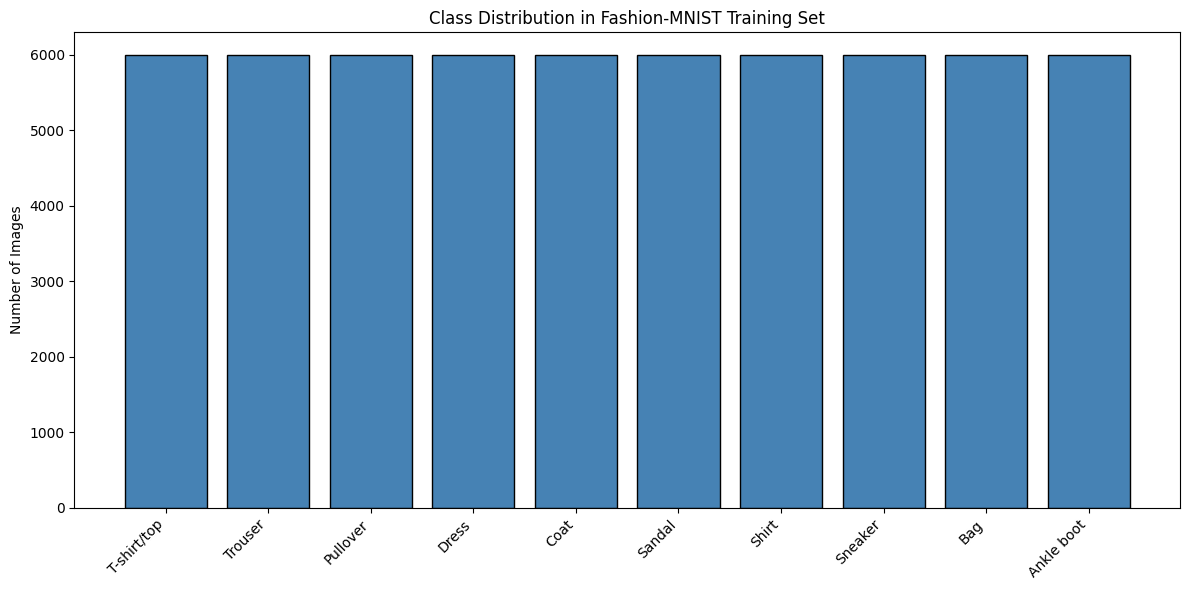

Class distribution plot saved to outputs/visualizations/class_distribution.png


In [6]:
targets = train_data.targets
class_counts = [(targets == i).sum().item() for i in range(len(class_names))]

plt.figure(figsize=(12, 6))
plt.bar(class_names, class_counts, color='steelblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Images')
plt.title('Class Distribution in Fashion-MNIST Training Set')
plt.tight_layout()
plt.savefig('outputs/visualizations/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('Class distribution plot saved to outputs/visualizations/class_distribution.png')

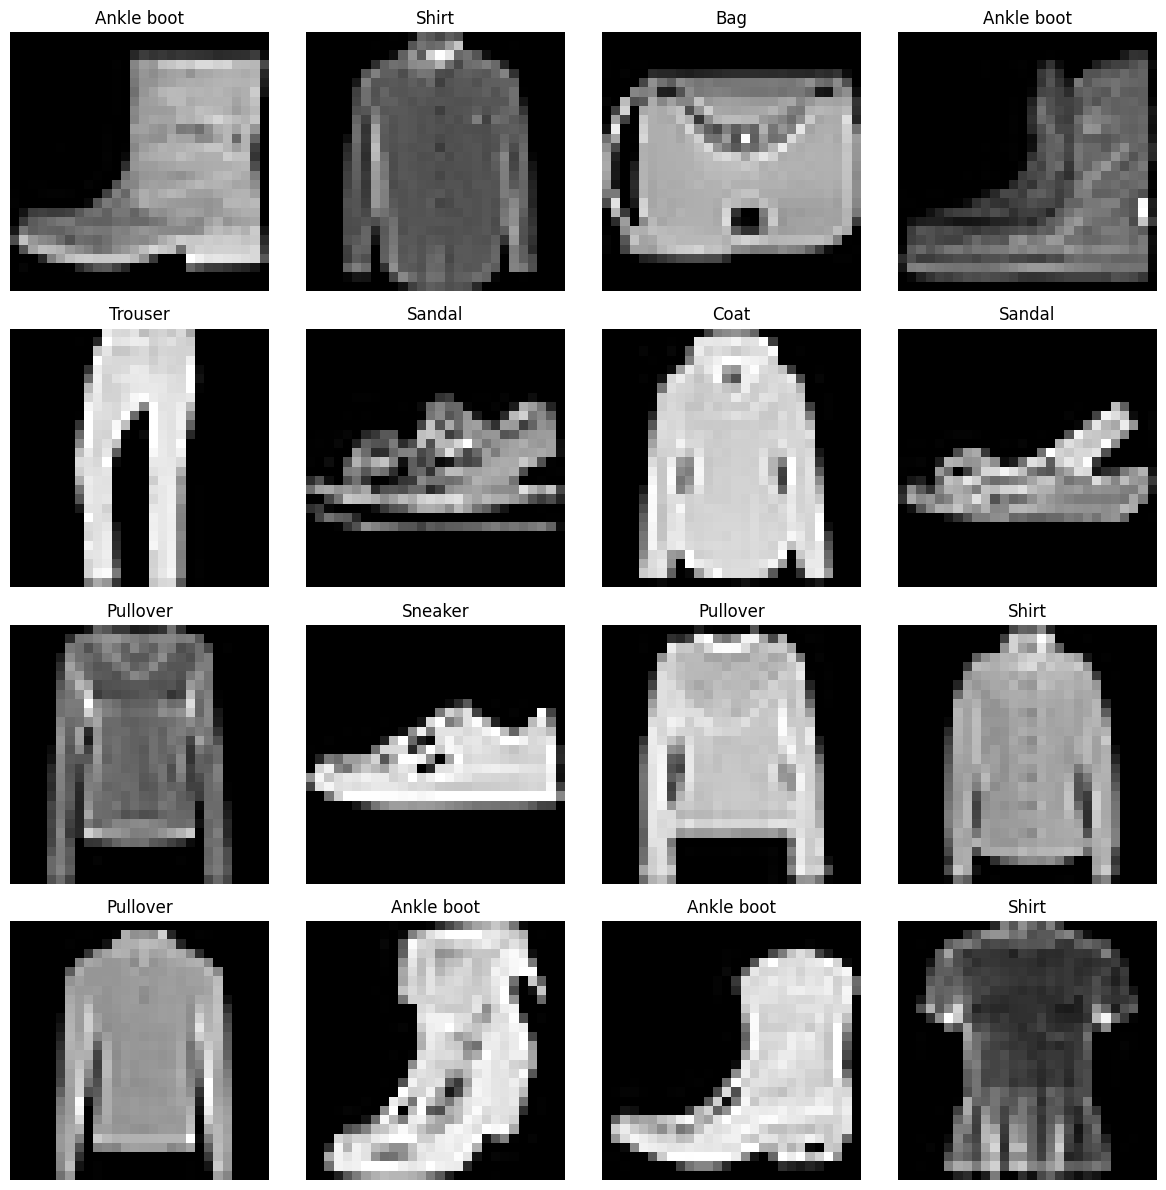

Sample images saved to outputs/visualizations/sample_images.png


In [7]:
torch.manual_seed(42)
fig = plt.figure(figsize=(12, 12))
rows, cols = 4, 4

for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(class_names[label])
    plt.axis('off')

plt.tight_layout()
plt.savefig('outputs/visualizations/sample_images.png', dpi=300, bbox_inches='tight')
plt.show()
print('Sample images saved to outputs/visualizations/sample_images.png')

In [8]:
BATCH_SIZE = 32

train_dataloader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Training batches: {len(train_dataloader)}")
print(f"Testing batches: {len(test_dataloader)}")
print(f"Batch size: {BATCH_SIZE}")

Training batches: 1875
Testing batches: 313
Batch size: 32


In [9]:
class Fashion_MNIST_classifier(nn.Module):
    def __init__(self, in_shape: int, hidden_units: int, out_shape: int):
        super().__init__()
        self.layer_block1 = nn.Sequential(
            nn.Conv2d(in_shape, hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.layer_block2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*7*7, out_features=out_shape)
        )

    def forward(self, x):
        x = self.layer_block1(x)
        x = self.layer_block2(x)
        x = self.classifier(x)
        return x

In [10]:
torch.manual_seed(42)

model = Fashion_MNIST_classifier(
    in_shape=1,
    hidden_units=10,
    out_shape=len(class_names)
).to(device)

print(model)

Fashion_MNIST_classifier(
  (layer_block1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer_block2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)


In [11]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

In [12]:
train_losses_history = []
test_losses_history = []
train_accs_history = []
test_accs_history = []

epochs = 10
best_test_loss = float('inf')

for epoch in tqdm(range(epochs)):
    print(f"\nEpoch: {epoch}")
    print("-" * 50)
    
    train_loss = 0
    train_acc = 0
    
    model.train()
    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)
        
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        acc = accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_acc += acc
    
    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)
    
    test_loss = 0
    test_acc = 0
    
    model.eval()
    with torch.inference_mode():
        for X_test, y_test in test_dataloader:
            X_test, y_test = X_test.to(device), y_test.to(device)
            
            pred_test = model(X_test)
            loss = loss_fn(pred_test, y_test)
            acc = accuracy_fn(y_true=y_test, y_pred=pred_test.argmax(dim=1))
            
            test_loss += loss.item()
            test_acc += acc
    
    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)
    
    train_losses_history.append(train_loss)
    test_losses_history.append(test_loss)
    train_accs_history.append(train_acc)
    test_accs_history.append(test_acc)
    
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'test_loss': test_loss,
            'train_acc': train_acc,
            'test_acc': test_acc
        }, 'models/fashion_mnist_best_model.pth')
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

print("\nTraining complete!")
print(f"Best test loss: {best_test_loss:.4f}")

  0%|          | 0/10 [00:00<?, ?it/s]


Epoch: 0
--------------------------------------------------
Train Loss: 0.5436 | Train Acc: 80.28%
Test Loss: 0.4075 | Test Acc: 85.09%

Epoch: 1
--------------------------------------------------
Train Loss: 0.3599 | Train Acc: 87.05%
Test Loss: 0.3498 | Test Acc: 87.50%

Epoch: 2
--------------------------------------------------
Train Loss: 0.3242 | Train Acc: 88.26%
Test Loss: 0.3446 | Test Acc: 87.45%

Epoch: 3
--------------------------------------------------
Train Loss: 0.3008 | Train Acc: 88.99%
Test Loss: 0.3178 | Test Acc: 88.70%

Epoch: 4
--------------------------------------------------
Train Loss: 0.2863 | Train Acc: 89.62%
Test Loss: 0.3195 | Test Acc: 88.66%

Epoch: 5
--------------------------------------------------
Train Loss: 0.2729 | Train Acc: 90.03%
Test Loss: 0.3062 | Test Acc: 89.13%

Epoch: 6
--------------------------------------------------
Train Loss: 0.2642 | Train Acc: 90.40%
Test Loss: 0.2938 | Test Acc: 89.32%

Epoch: 7
-------------------------------

In [13]:
torch.save({
    'epoch': epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_loss': train_losses_history[-1],
    'test_loss': test_losses_history[-1],
    'train_acc': train_accs_history[-1],
    'test_acc': test_accs_history[-1],
    'train_history': {
        'train_losses': train_losses_history,
        'test_losses': test_losses_history,
        'train_accs': train_accs_history,
        'test_accs': test_accs_history
    }
}, 'models/fashion_mnist_final_model.pth')

print('Final model saved to models/fashion_mnist_final_model.pth')

Final model saved to models/fashion_mnist_final_model.pth


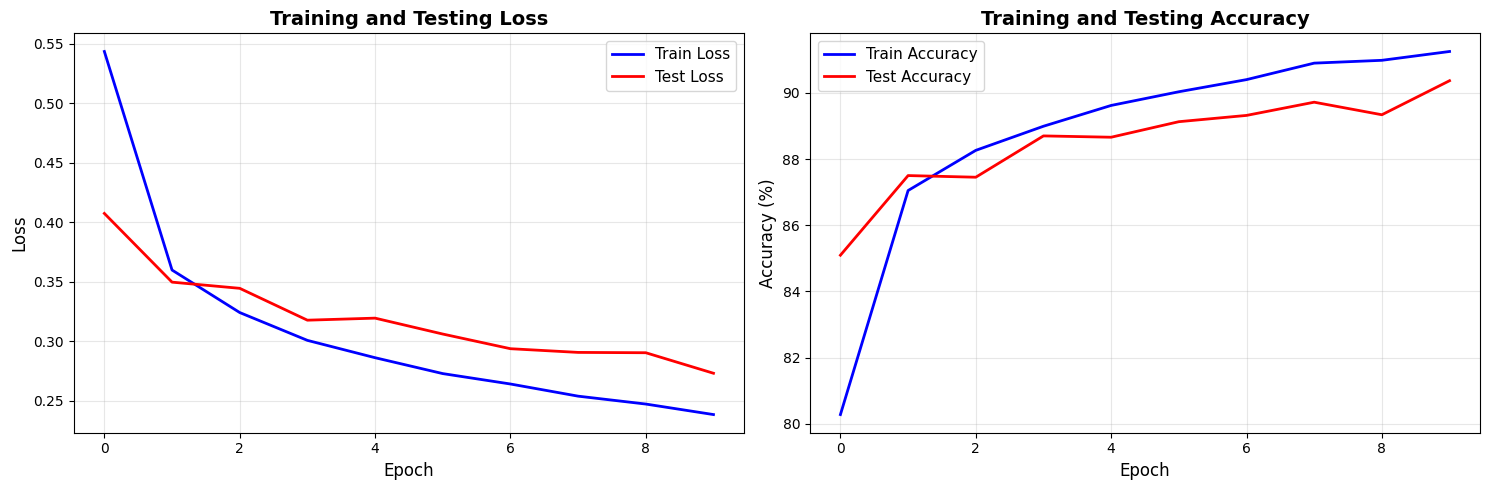

Training history saved to outputs/visualizations/training_history.png


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(train_losses_history, label='Train Loss', linewidth=2, color='blue')
ax1.plot(test_losses_history, label='Test Loss', linewidth=2, color='red')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Testing Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs_history, label='Train Accuracy', linewidth=2, color='blue')
ax2.plot(test_accs_history, label='Test Accuracy', linewidth=2, color='red')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training and Testing Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/visualizations/training_history.png', dpi=300, bbox_inches='tight')
plt.show()
print('Training history saved to outputs/visualizations/training_history.png')

In [15]:
y_preds = []

model.eval()
with torch.inference_mode():
    for X, y in tqdm(test_dataloader, desc="Making predictions"):
        X, y = X.to(device), y.to(device)
        y_logits = model(X)
        y_pred = y_logits.argmax(dim=1)
        y_preds.append(y_pred.cpu())

y_pred_tensor = torch.cat(y_preds)
print(f"Total predictions: {len(y_pred_tensor)}")

Making predictions:   0%|          | 0/313 [00:00<?, ?it/s]

Total predictions: 10000


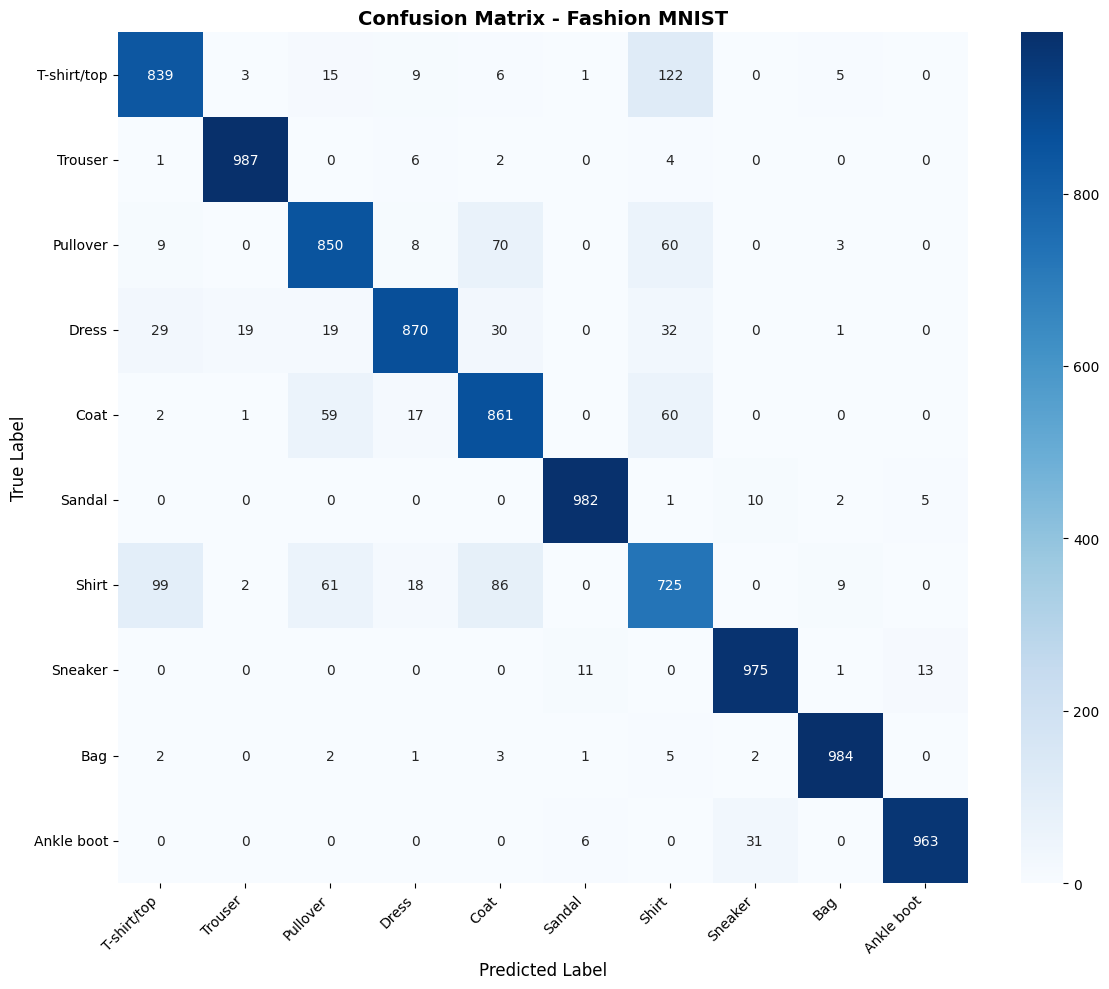

Confusion matrix saved to outputs/visualizations/confusion_matrix.png


In [16]:
y_test = []
for X, y in test_dataloader:
    y_test.extend(y.numpy())

cm = confusion_matrix(y_test, y_pred_tensor.numpy())

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Fashion MNIST', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs/visualizations/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print('Confusion matrix saved to outputs/visualizations/confusion_matrix.png')

In [17]:
report = classification_report(y_test, y_pred_tensor.numpy(), target_names=class_names, digits=4)
print(report)

with open('outputs/classification_report.txt', 'w') as f:
    f.write(report)
print('\nClassification report saved to outputs/classification_report.txt')

              precision    recall  f1-score   support

 T-shirt/top     0.8552    0.8390    0.8470      1000
     Trouser     0.9753    0.9870    0.9811      1000
    Pullover     0.8449    0.8500    0.8475      1000
       Dress     0.9365    0.8700    0.9020      1000
        Coat     0.8138    0.8610    0.8367      1000
      Sandal     0.9810    0.9820    0.9815      1000
       Shirt     0.7185    0.7250    0.7218      1000
     Sneaker     0.9578    0.9750    0.9663      1000
         Bag     0.9791    0.9840    0.9815      1000
  Ankle boot     0.9817    0.9630    0.9722      1000

    accuracy                         0.9036     10000
   macro avg     0.9044    0.9036    0.9038     10000
weighted avg     0.9044    0.9036    0.9038     10000


Classification report saved to outputs/classification_report.txt


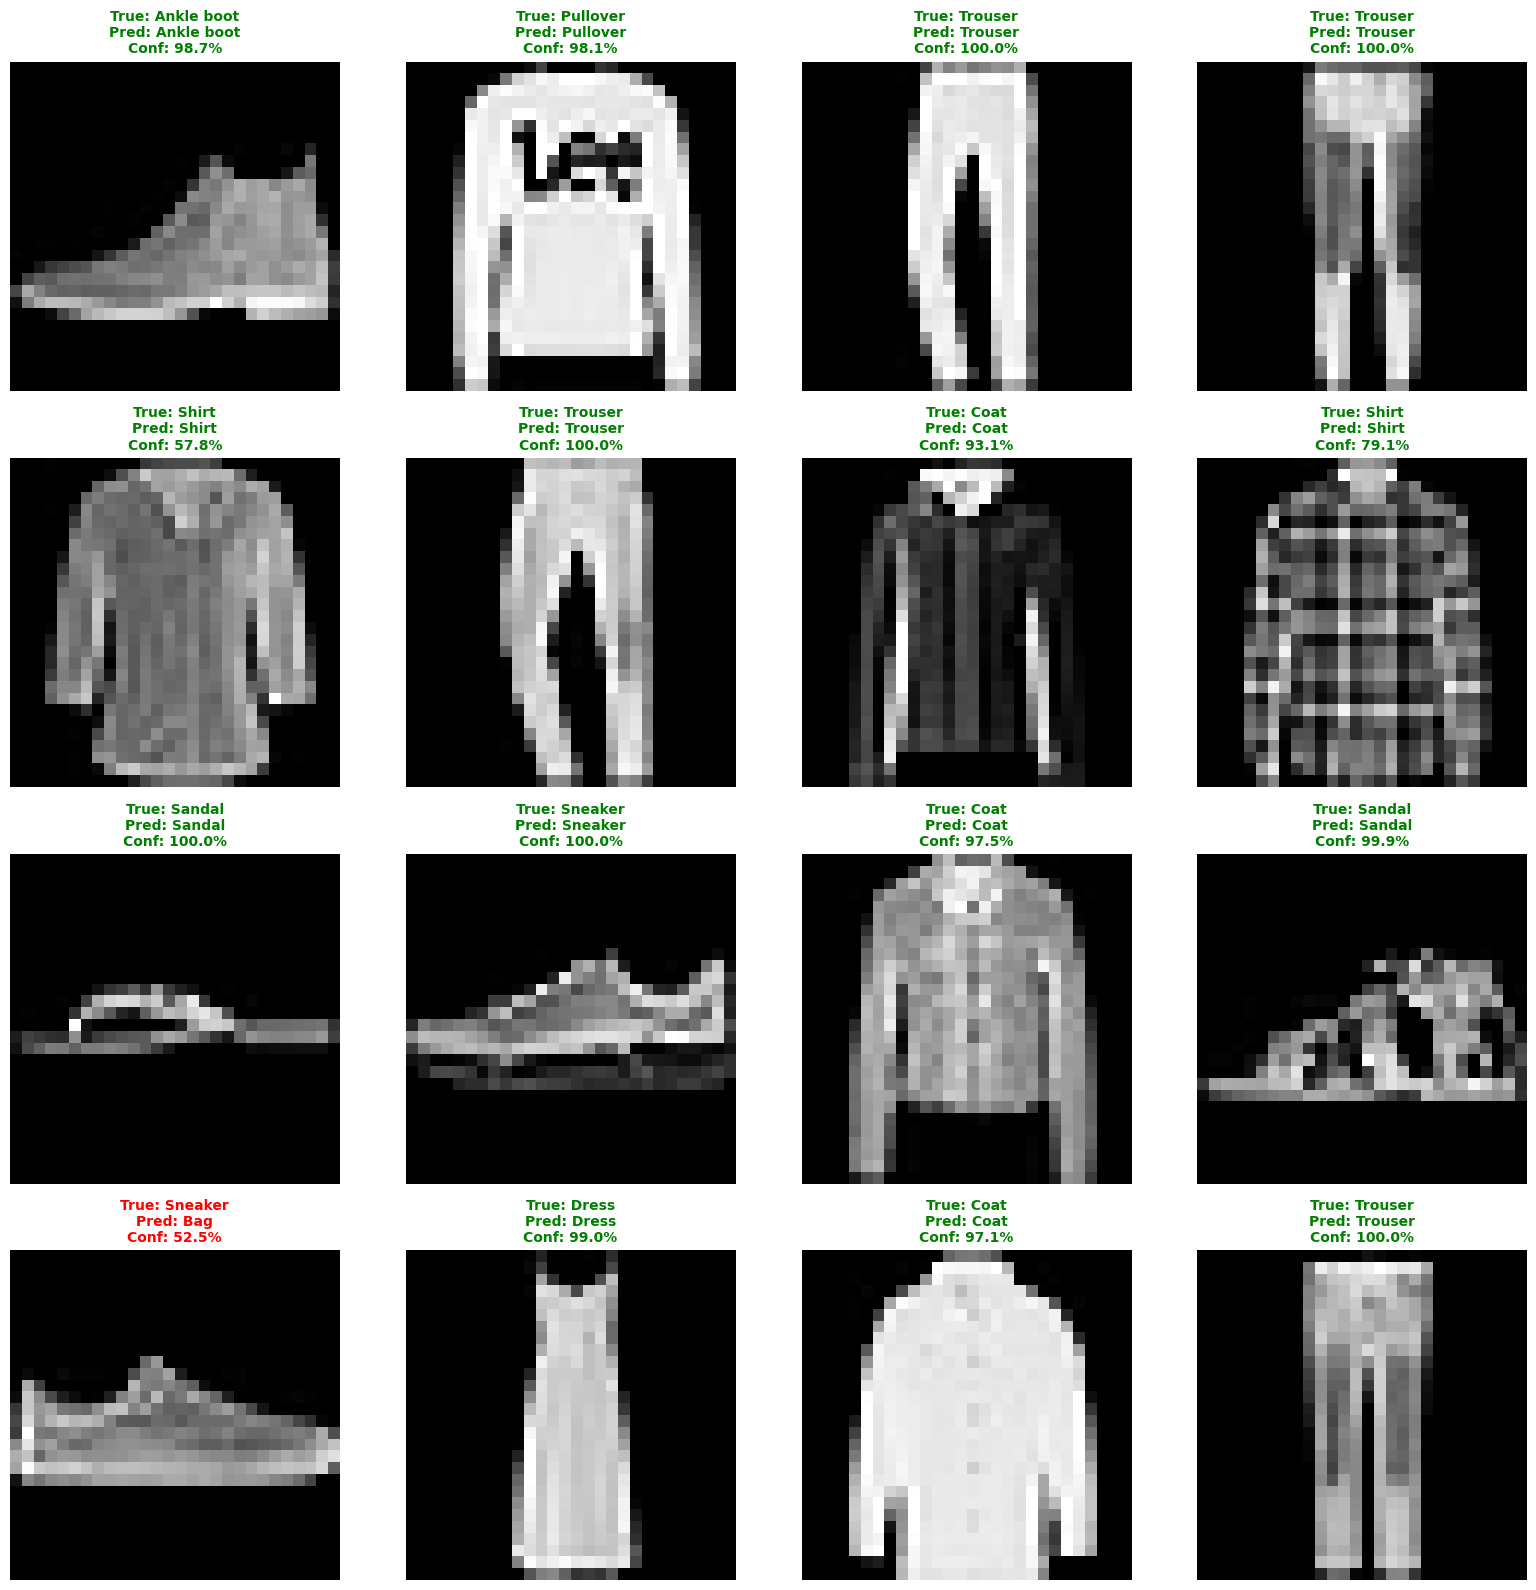

Sample predictions saved to outputs/visualizations/sample_predictions.png


In [18]:
test_samples_iter = iter(test_dataloader)
test_images, test_labels = next(test_samples_iter)
test_images = test_images.to(device)
test_labels = test_labels.to(device)

model.eval()
with torch.inference_mode():
    test_preds = model(test_images)
    pred_labels = test_preds.argmax(dim=1)
    pred_probs = torch.softmax(test_preds, dim=1)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for idx, ax in enumerate(axes.flat):
    img = test_images[idx].cpu().squeeze()
    true_label = test_labels[idx].cpu().item()
    pred_label = pred_labels[idx].cpu().item()
    confidence = pred_probs[idx][pred_label].cpu().item() * 100
    
    ax.imshow(img, cmap='gray')
    color = 'green' if pred_label == true_label else 'red'
    title = f'True: {class_names[true_label]}\nPred: {class_names[pred_label]}\nConf: {confidence:.1f}%'
    ax.set_title(title, color=color, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('outputs/visualizations/sample_predictions.png', dpi=300, bbox_inches='tight')
plt.show()
print('Sample predictions saved to outputs/visualizations/sample_predictions.png')

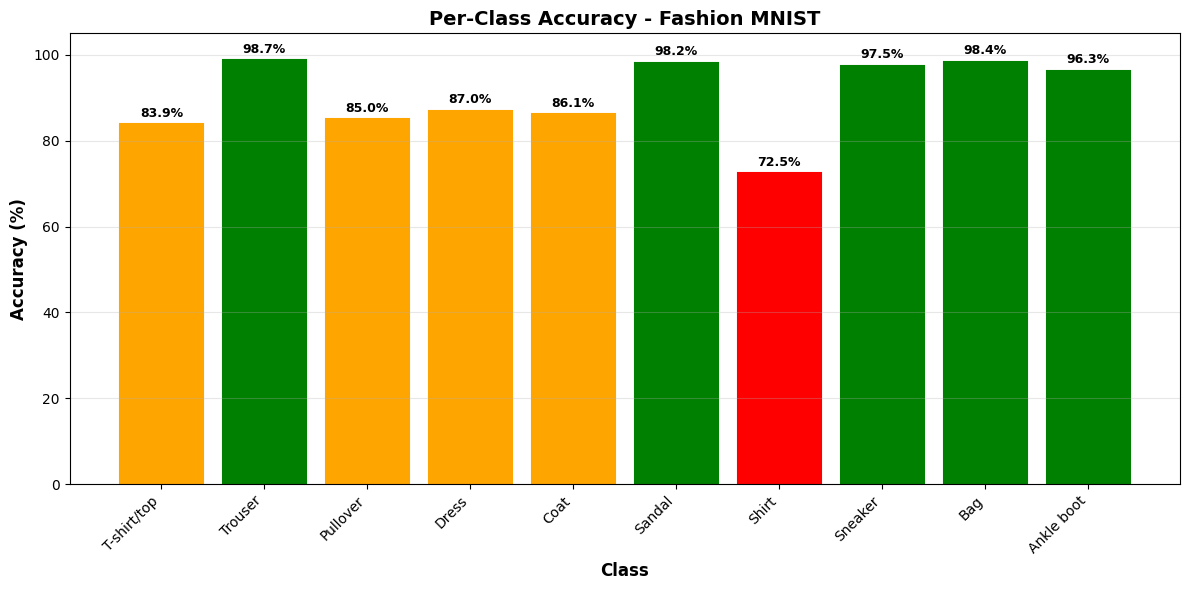


Per-Class Accuracy:
T-shirt/top     :  839/1000 ( 83.90%)
Trouser         :  987/1000 ( 98.70%)
Pullover        :  850/1000 ( 85.00%)
Dress           :  870/1000 ( 87.00%)
Coat            :  861/1000 ( 86.10%)
Sandal          :  982/1000 ( 98.20%)
Shirt           :  725/1000 ( 72.50%)
Sneaker         :  975/1000 ( 97.50%)
Bag             :  984/1000 ( 98.40%)
Ankle boot      :  963/1000 ( 96.30%)
Overall Accuracy: 9036/10000 (90.36%)

Per-class accuracy plot saved to outputs/visualizations/per_class_accuracy.png


In [19]:
class_correct = [0] * len(class_names)
class_total = [0] * len(class_names)

model.eval()
with torch.inference_mode():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        preds = model(X)
        pred_labels = preds.argmax(dim=1)
        
        for true_label, pred_label in zip(y, pred_labels):
            class_total[true_label] += 1
            if true_label == pred_label:
                class_correct[true_label] += 1

class_accuracies = [100 * class_correct[i] / class_total[i] for i in range(len(class_names))]

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(class_names)), class_accuracies, edgecolor='black', linewidth=1.5)

for i, (bar, acc) in enumerate(zip(bars, class_accuracies)):
    if acc >= 90:
        bar.set_color('green')
    elif acc >= 80:
        bar.set_color('orange')
    else:
        bar.set_color('red')

plt.xlabel('Class', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
plt.title('Per-Class Accuracy - Fashion MNIST', fontsize=14, fontweight='bold')
plt.xticks(range(len(class_names)), class_names, rotation=45, ha='right')
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)

for i, (bar, acc) in enumerate(zip(bars, class_accuracies)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/visualizations/per_class_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nPer-Class Accuracy:')
print('=' * 60)
for i, (name, acc) in enumerate(zip(class_names, class_accuracies)):
    print(f'{name:15} : {class_correct[i]:4d}/{class_total[i]:4d} ({acc:6.2f}%)')
print('=' * 60)
print(f'Overall Accuracy: {sum(class_correct)}/{sum(class_total)} ({100*sum(class_correct)/sum(class_total):.2f}%)')
print('\nPer-class accuracy plot saved to outputs/visualizations/per_class_accuracy.png')

In [20]:
print('=' * 70)
print(' ' * 20 + 'TRAINING SUMMARY')
print('=' * 70)
print(f'Final Training Accuracy: {train_accs_history[-1]:.2f}%')
print(f'Final Testing Accuracy: {test_accs_history[-1]:.2f}%')
print(f'Best Test Loss: {best_test_loss:.4f}')
print('\nGenerated Files:')
print('  Models:')
print('    - models/fashion_mnist_best_model.pth')
print('    - models/fashion_mnist_final_model.pth')
print('\n  Visualizations:')
print('    - outputs/visualizations/class_distribution.png')
print('    - outputs/visualizations/sample_images.png')
print('    - outputs/visualizations/training_history.png')
print('    - outputs/visualizations/confusion_matrix.png')
print('    - outputs/visualizations/sample_predictions.png')
print('    - outputs/visualizations/per_class_accuracy.png')
print('\n  Reports:')
print('    - outputs/classification_report.txt')
print('=' * 70)

                    TRAINING SUMMARY
Final Training Accuracy: 91.25%
Final Testing Accuracy: 90.37%
Best Test Loss: 0.2732

Generated Files:
  Models:
    - models/fashion_mnist_best_model.pth
    - models/fashion_mnist_final_model.pth

  Visualizations:
    - outputs/visualizations/class_distribution.png
    - outputs/visualizations/sample_images.png
    - outputs/visualizations/training_history.png
    - outputs/visualizations/confusion_matrix.png
    - outputs/visualizations/sample_predictions.png
    - outputs/visualizations/per_class_accuracy.png

  Reports:
    - outputs/classification_report.txt
